# Install package

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# !nvidia-smi

In [3]:
!pip install mat4py
!pip show tensorflow
!pip install tensorflow
!pip show gym
!pip install gym
from google.colab import drive
drive.mount('/content/drive')
from scipy.io import loadmat
from scipy.io import savemat
import os
os.chdir('/content/drive/My Drive')

Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: 
Name: gym
Version: 0.26.2
Summary: Gym: A universal API for reinforcement learning environments
Home-page: https://www.gymlibrary.dev/
Author: Gym Community
Author-email: jkterry@umd.edu
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: cloudpickle, gym_notices, numpy
Required-by: 
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 首先确保 TensorFlow 安装
try:
    import tensorflow as tf
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)

    # 或者限制 GPU 內存使用量
    if gpus:
        try:
            tf.config.experimental.set_memory_growth(gpus[0], True)
            # 或者設置內存限制
            # tf.config.experimental.set_virtual_device_configuration(
            #     gpus[0],
            #     [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=4096)])
        except RuntimeError as e:
            print(e)
    print(f"TensorFlow 版本: {tf.__version__}")
except ImportError:
    print("正在安装 TensorFlow...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    import tensorflow as tf
    print(f"TensorFlow 版本: {tf.__version__}")

# 其他导入
import collections
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import gym
import os
import random
import sys
from gym import spaces
from gym.utils import seeding
import copy
from mat4py import loadmat
import time

# TensorFlow 相关导入
from tensorflow import keras
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.layers import RNN
import tensorflow.keras.backend as K

# 设置 numpy 打印选项
np.set_printoptions(precision=16)

print("所有导入成功完成！")

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow 版本: 2.20.0
所有导入成功完成！


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


# Environment Setup

In [5]:
# Transient Frequency Control Porblem Environment
class Transient_Frequency(gym.Env):
    def  __init__(self,M,E,Pm,D,D_reactance,delta_t,omega_max,omega_min,dim_omega,dim_lambda,Penalty_action):
        self.param_gamma=1
        self.M=M
        self.E=E
        self.Pm=Pm
        self.D=D
        self.D_reactance=D_reactance
        self.delta_t=delta_t
        self.omega_max=omega_max
        self.omega_min=omega_min
        self.dim_omega=dim_omega
        self.dim_lambda=dim_lambda
        self.Penalty_action=Penalty_action
        self.viewer = None
        self.state=[]

        self.state_transfer1=np.vstack((np.hstack((np.identity((dim_lambda)),np.zeros((dim_lambda,dim_omega)))),\
          np.hstack((delta_t*np.transpose(D),np.identity((dim_omega))-delta_t*np.diag(np.squeeze(E/M))))))

        self.state_transfer2=np.hstack((np.zeros((dim_omega,dim_lambda)),np.identity((dim_omega))))

        self.state_transfer3=np.hstack((np.zeros((dim_omega,dim_lambda)),delta_t*(np.diag(np.squeeze((M**(-1)))))))

        self.select_add_omega=np.vstack((np.zeros((dim_lambda,1)),np.ones((dim_omega,1))))

        self.select_omega=np.vstack((np.zeros((dim_lambda,dim_omega)),np.identity(dim_omega)))

        self.select_lambda=np.vstack((np.identity(dim_lambda),np.zeros((dim_omega,dim_lambda))))

    def step(self,action,Pm):
        self.state=copy.deepcopy(self.state@self.state_transfer1 \
                -((delta_t*((np.sin(self.state@self.select_lambda))@D_reactance)@D)*(M**(-1)))@self.state_transfer2 \
                    + (Pm+action)@self.state_transfer3)

        loss = self.param_gamma*pow(self.state,2)@self.select_add_omega
        return self.state, loss

    def set_state(self, state_input):
        self.state=state_input

In [6]:
DATA_SCL = '/content/drive/MyDrive/Colab Notebooks/SCL/data'

D = np.asarray(loadmat(f'{DATA_SCL}/IEEE-39-adjacency-matrix.mat')['D'], dtype=np.float32)
Power_initial = np.asarray(loadmat(f'{DATA_SCL}/IEEE-39-power-initial-balanced.mat')['power_initial'], dtype=np.float32)
Rotational_inertial_generator = np.asarray(loadmat(f'{DATA_SCL}/IEEE-39-rotational-inertial-generator.mat')['rotational_inertial_generator'], dtype=np.float32)
Rotational_inertial_load = np.asarray(loadmat(f'{DATA_SCL}/IEEE-39-rotational-inertial-load.mat')['rotational_inertial_load'], dtype=np.float32)
D_reactance = np.asarray(loadmat(f'{DATA_SCL}/IEEE-39-susceptance-matrix.mat')['D_reactance'], dtype=np.float32)

In [7]:
dim_omega=39 #dimension of action space
dim_lambda=46 #dimension of lambda
dim_state=dim_omega+dim_lambda #dimension of state space
action_units=dim_omega
delta_t=0.0008
M=((np.vstack((Rotational_inertial_load,Rotational_inertial_generator)))[:,1]).reshape(1,dim_omega)
E=1*np.ones((1,dim_omega),dtype=np.float32)
L=np.transpose(D)@(D_reactance)@D
Laplacian=np.transpose(D)@D
A_nom=-Laplacian+np.diag(np.diag(Laplacian))
syn_frequence=np.sum(Power_initial,axis=0)/np.sum(E,axis=1)
f_initial=D@np.linalg.pinv(L)@(Power_initial-syn_frequence*np.transpose(E))
Pm=np.transpose(Power_initial)
Pm_nominal=copy.deepcopy(Pm)
omega_max=0.2
omega_min=-0.2
#Penalty_action=40
#Penalty_action=40*200
Penalty_action=40*2
equilibrium_init=np.hstack((np.transpose(f_initial),syn_frequence*np.ones((1,dim_omega))))

# ESS 參數 - 從ESS代碼中引入
E_upper = 0.3 * np.ones((1, dim_omega), dtype=np.float32)
E_lower = -E_upper
Pe_upper = 1.0 * np.ones((1, dim_omega), dtype=np.float32)
Pe_lower = -Pe_upper

env = Transient_Frequency(M,E,Pm,D,D_reactance,delta_t,omega_max,omega_min,dim_omega,dim_lambda,Penalty_action)

# Init Simulation

In [8]:
#Controller in Zhang & Cortes (2019)
def Action_Yifu(state,env):
    states_controlled=state@env.select_omega
    alpha_plus = 2*(states_controlled-omega_max*np.ones((dim_omega,)))
    alpha_minus = 2*(omega_min*np.ones((dim_omega,))-states_controlled)
    q_xp = E*states_controlled+(np.sin(state@env.select_lambda)@D_reactance)@D-Pm
    omega_th_max=(0.5*omega_max*np.ones((dim_omega,)))
    omega_th_min=(0.5*omega_min*np.ones((dim_omega,)))
    def getBinaryNumpy(imgNumpy, boundary=0):
        one = np.ones_like(imgNumpy)
        zero = np.zeros_like(imgNumpy)
        return np.where(imgNumpy>boundary, one, zero)
    nonlinear_plus = getBinaryNumpy(states_controlled-omega_th_max, boundary=0)*\
      np.minimum(np.zeros(dim_omega,), -alpha_plus*((states_controlled-omega_th_max)**(-1))+q_xp)
    nonlinear_minus = getBinaryNumpy(omega_th_min-state@env.select_omega, boundary=0)*\
      np.maximum(np.zeros(dim_omega,), alpha_minus*((omega_th_min-states_controlled)**(-1))+q_xp)

    action = nonlinear_plus + nonlinear_minus
    return action

<>:84: SyntaxWarning: invalid escape sequence '\o'
<>:94: SyntaxWarning: invalid escape sequence '\l'
<>:84: SyntaxWarning: invalid escape sequence '\o'
<>:94: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-731651751.py:84: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$\omega$ (rad/s)', fontsize=14)
/tmp/ipython-input-731651751.py:94: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\lambda$ (rad)', fontsize=14)


array([[-0.1020185351371765, -0.0664615891873837,  0.0615515140816569,
         0.0325384493917227, -0.0457923098001629,  0.0557890068739653,
        -0.0695593319833279,  0.0232483986765146, -0.0556685570627451,
        -0.06059730052948  ,  0.                , -0.06059730052948  ,
        -0.1265146695077419,  0.                ,  0.0556328780949116,
        -0.100067550316453 ,  0.                ,  0.0112666007771622,
        -0.1255373656749725, -0.0405515199527144, -0.0292849192628637,
         0.0363311236724257, -0.1177697237581015,  0.0589332189410925,
         0.0356239099055529, -0.2319623250514269, -0.0393542684614658,
         0.0251662640366703, -0.0464672045782208,  0.0406915759667754,
        -0.0093132473994046,  0.1905131861567497, -0.1951466717291623,
        -0.057047925889492 ,  0.0321626854129136, -0.120948116062209 ,
         0.0894058533012867, -0.1372604854404926, -0.0017220079898834,
        -0.1761167587828822,  0.0483345184475183, -0.1371744908392429,
      

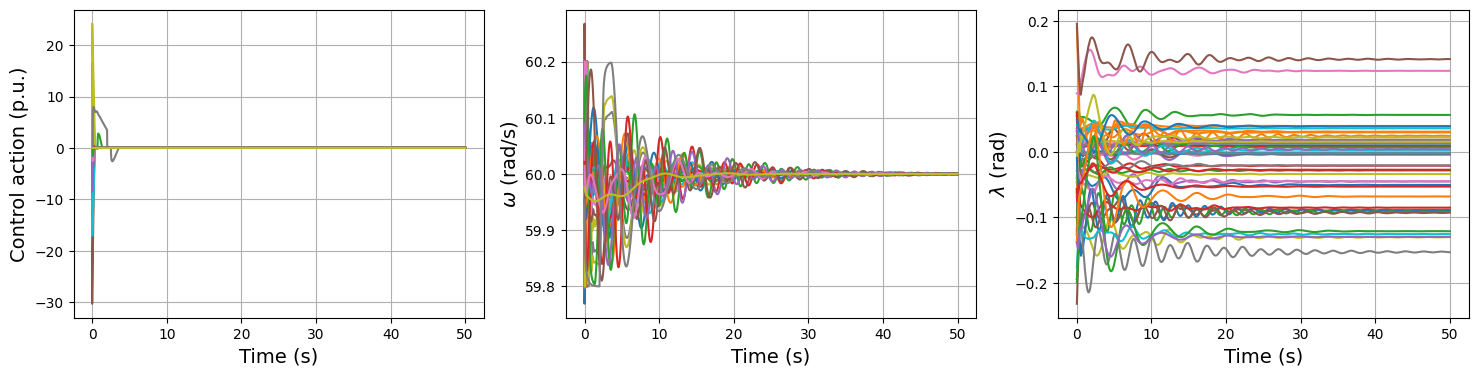

In [9]:
# Plot the trajectory to visulize the performance of control

Trajectory_Linear_omega=[]
Trajectory_Linear_omega_true=[]
Trajectory_Linear_lambda=[]

initial_state1=np.transpose(D@np.linalg.pinv(L)@(Power_initial*np.random.uniform(-0.1,0.1,(dim_omega,1))-syn_frequence*np.transpose(E)))
initial_state2=np.random.uniform(-0.1,0.1,(1,dim_omega))*1
s_concate=np.hstack((initial_state1,initial_state2)).astype(np.float32)

init_state=equilibrium_init + s_concate
#
s=init_state
s_record_all_omega = s@env.select_omega
s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_omega))
s_record_all_lambda = s@env.select_lambda
env.set_state(s)
Trajectory_Linear_omega.append(s_record_all_omega)
Trajectory_Linear_omega_true.append(s_record_all_omega_true)
Trajectory_Linear_lambda.append(s_record_all_lambda)
Test_time=50
SimulationLength=int(Test_time/delta_t)
Record_u_Linear=[]
Record_Loss_Linear=[]
Loss_Linear=0

generator_loss_node = 38
# generator_loss_node_1 = 38
# generator_loss_node_2 = 35
# generator_loss_node_3 = 33
# generator_loss_node_4 = 32

generator_loss_start_time = 0
generator_loss_period = 2
for i in range(SimulationLength):
    if i>=generator_loss_start_time/delta_t and i<=(generator_loss_start_time+generator_loss_period)/delta_t:
      Pm[0,generator_loss_node-1] = 0
      # Pm[0,generator_loss_node_1-1] = 0
      # Pm[0,generator_loss_node_2-1] = 0
      # Pm[0,generator_loss_node_3-1] = 0
      # Pm[0,generator_loss_node_4-1] = 0
    else:
      Pm[0,generator_loss_node-1] = Pm_nominal[0,generator_loss_node-1]
      # Pm[0,generator_loss_node_1-1] = Pm_nominal[0,generator_loss_node_1-1]
      # Pm[0,generator_loss_node_2-1] = Pm_nominal[0,generator_loss_node_2-1]
      # Pm[0,generator_loss_node_3-1] = Pm_nominal[0,generator_loss_node_3-1]
      # Pm[0,generator_loss_node_4-1] = Pm_nominal[0,generator_loss_node_4-1]
    u=Action_Yifu(s,env)
    next_s, r= env.step(u,Pm)
    Loss_Linear+=r
    s=next_s
    s_record_all_omega = s@env.select_omega
    s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_omega))
    s_record_all_lambda = s@env.select_lambda
    Trajectory_Linear_omega.append(s_record_all_omega)
    Trajectory_Linear_omega_true.append(s_record_all_omega_true)
    Trajectory_Linear_lambda.append(s_record_all_lambda)
    Record_u_Linear.append(u)
    Record_Loss_Linear.append(np.squeeze(r))

Trajectory_Linear_omega=np.squeeze(np.asarray(Trajectory_Linear_omega))
Trajectory_Linear_omega_true=np.squeeze(np.asarray(Trajectory_Linear_omega_true))
Trajectory_Linear_lambda=np.squeeze(np.asarray(Trajectory_Linear_lambda))
Record_u_Linear=np.squeeze(np.asarray(Record_u_Linear))

plt.figure(figsize=(18,4), dpi=100)
TimeRecord=np.arange(1,SimulationLength+1)
TimeRecord=env.delta_t*TimeRecord
plt.subplot(1,3,1)

plt.plot(TimeRecord,Record_u_Linear)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Control action (p.u.)', fontsize=14)


plt.subplot(1,3,2)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_omega_true)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\omega$ (rad/s)', fontsize=14)


plt.subplot(1,3,3)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_lambda)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\lambda$ (rad)', fontsize=14)
init_state

In [10]:
(np.sum(np.power(Record_u_Linear,2))+env.Penalty_action*np.sum(np.power(Trajectory_Linear_omega,2)))/(50/0.0008)

np.float64(9.506133672757938)

# RNN

In [11]:
# # 從ESS代碼中引入關鍵函數

def get_inside_bound(input, boundary_upper, boundary_lower):
    """檢查是否在邊界內"""
    zero = tf.zeros_like(input, dtype=tf.float32)
    one = tf.ones_like(input, dtype=tf.float32)
    scale_factor_upper = tf.where(input <= boundary_upper, one, zero)
    scale_factor_lower = tf.where(input >= boundary_lower, one, zero)
    return scale_factor_upper * scale_factor_lower

def get_below_bound(input, boundary_lower):
    """檢查是否低於下邊界"""
    zero = tf.zeros_like(input, dtype=tf.float32)
    one = tf.ones_like(input, dtype=tf.float32)
    scale_factor = tf.where(input < boundary_lower, one, zero)
    return scale_factor

def get_beyond_bound(input, boundary_upper):
    """檢查是否超過上邊界"""
    zero = tf.zeros_like(input, dtype=tf.float32)
    one = tf.ones_like(input, dtype=tf.float32)
    scale_factor = tf.where(input > boundary_upper, one, zero)
    return scale_factor

In [12]:
# # RNN Cell - 整合ESS功能到RLB框架
global count_num
count_num = 0

class MinimalRNNCell_RLB_ESS(keras.layers.Layer):
    def __init__(self, units, action_units, internal_units, env, batchsize, **kwargs):
        self.units = units
        self.state_size = units
        self.action_units = action_units
        self.internal_units = internal_units
        self.batchsize = batchsize

        # 使用 CPU 創建常量
        with tf.device('/CPU:0'):
            self.state_transfer1 = tf.constant(env.state_transfer1, dtype=tf.float32)
            self.state_transfer2 = tf.constant(env.state_transfer2, dtype=tf.float32)
            self.state_transfer3 = tf.constant(env.state_transfer3, dtype=tf.float32)
            self.select_add_omega = tf.constant(env.select_add_omega, dtype=tf.float32)
            self.select_omega = tf.constant(env.select_omega, dtype=tf.float32)
            self.select_lambda = tf.constant(env.select_lambda, dtype=tf.float32)

            self.weight_recover = tf.constant(
                tf.linalg.band_part(-tf.ones((internal_units, internal_units), dtype=tf.float32), 0, 1) +
                2 * tf.eye(internal_units, dtype=tf.float32), dtype=tf.float32)
            self.bias_recover = tf.constant(
                tf.linalg.band_part(tf.ones((internal_units, internal_units), dtype=tf.float32), 0, -1) -
                tf.eye(internal_units, dtype=tf.float32), dtype=tf.float32)
            self.ones_frequency = tf.ones((action_units, internal_units), dtype=tf.float32)

        # ESS 參數
        self.E_upper = tf.constant(E_upper, dtype=tf.float32)
        self.E_lower = tf.constant(E_lower, dtype=tf.float32)
        self.Pe_upper = tf.constant(Pe_upper, dtype=tf.float32)
        self.Pe_lower = tf.constant(Pe_lower, dtype=tf.float32)

        super(MinimalRNNCell_RLB_ESS, self).__init__(**kwargs)

    def build(self, input_shape):
        # RLB 原有權重
        self.w_plus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.01, maxval=0.01),
            trainable=True,
            name='w_plus_temp')

        self.b_plus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=0.01),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.1),
            name='b_plus_temp')

        self.w_minus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.01, maxval=0.01),
            trainable=True,
            name='w_minus_temp')

        self.b_minus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=0.01),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.1),
            name='b_minus_temp')

        # omega_threshold
        self.t_plus_temp = self.add_weight(
            shape=(self.action_units,),
            initializer=tf.keras.initializers.Constant(0.0),
            trainable=True,
            name='t_plus_temp')

        self.t_minus_temp = self.add_weight(
            shape=(self.action_units,),
            initializer=tf.keras.initializers.Constant(0.0),
            trainable=True,
            name='t_minus_temp')

        # budgets
        self.d_temp = self.add_weight(
            shape=(1, self.action_units),
            initializer=tf.keras.initializers.Constant(0.0),
            trainable=True,
            name='d_temp')

        # controls
        self.q_plus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.01, maxval=0.01),
            trainable=True,
            name='q_plus_temp')

        self.c_plus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.01, maxval=0.01),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.1),
            name='c_plus_temp')

        self.q_minus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.01, maxval=0.01),
            trainable=True,
            name='q_minus_temp')

        self.c_minus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.01, maxval=0.01),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.1),
            name='c_minus_temp')

        # ESS 相關權重 - 從ESS代碼引入
        self.thr_upper_temp = self.add_weight(
            shape=(self.action_units,),
            initializer=tf.keras.initializers.Constant(0.9),
            trainable=True,
            name='thr_upper_temp')

        self.thr_lower_temp = self.add_weight(
            shape=(self.action_units,),
            initializer=tf.keras.initializers.Constant(0.1),
            trainable=True,
            name='thr_lower_temp')

        self.built = True

    def call(self, inputs, states):
        global count_num

        # 獲取批次大小
        batch_size = tf.shape(states[0])[0]

        # 發電機故障模擬
        Pm_current = tf.constant(Pm_nominal, dtype=tf.float32)

        prev_output = states[0]

        # RLB 原有計算
        w_plus_temp = tf.math.abs(self.w_plus_temp0)
        b_plus_temp = tf.math.abs(self.b_plus_temp0)
        w_minus_temp = tf.math.abs(self.w_minus_temp0)
        b_minus_temp = tf.math.abs(self.b_minus_temp0)
        w_plus = K.dot(-w_plus_temp, self.weight_recover)
        b_plus = K.dot(-b_plus_temp, self.bias_recover)
        w_minus = K.dot(-w_minus_temp, self.weight_recover)
        b_minus = K.dot(-b_minus_temp, self.bias_recover)

        d = K.dot(self.d_temp, tf.eye(self.action_units, dtype=tf.float32))

        q_plus = self.q_plus_temp0
        c_plus = -tf.math.abs(self.c_plus_temp0)
        q_minus = self.q_minus_temp0
        c_minus = -tf.math.abs(self.c_minus_temp0)

        omega_th_max = omega_max * K.sigmoid(self.t_plus_temp)
        omega_th_min = omega_min * K.sigmoid(self.t_minus_temp)

        def getBinaryTensor(imgTensor, boundary=0):
            one = tf.ones_like(imgTensor, dtype=tf.float32)
            zero = tf.zeros_like(imgTensor)
            return tf.where(imgTensor > boundary, one, zero)

        states_controlled = K.dot(prev_output, self.select_omega)

        status = getBinaryTensor(states_controlled - omega_th_max) + getBinaryTensor(omega_th_min - states_controlled)

        # 修復：確保 status 有正確的形狀
        status_expanded = tf.expand_dims(status, -1)  # [batch_size, action_units, 1]
        status_expanded_t = tf.expand_dims(status, 1)  # [batch_size, 1, action_units]

        A_tilde = A_nom * status_expanded * status_expanded_t
        Laplacian_tilde_diag = tf.reduce_sum(A_tilde, axis=2)
        Laplacian_tilde = -A_tilde + tf.linalg.diag(Laplacian_tilde_diag)

        budgets_temp = tf.matmul(d, Laplacian_tilde)  # [batch_size, 1, action_units]
        budgets_temp = tf.squeeze(budgets_temp, axis=1)  # [batch_size, action_units]

        # 修復：計算 alpha_plus 和 alpha_minus
        states_controlled_expanded = tf.expand_dims(states_controlled, -1)  # [batch_size, action_units, 1]

        # 修復 alpha_plus 計算
        alpha_plus_input = -tf.matmul(
            tf.linalg.diag(tf.squeeze(states_controlled - env.omega_max * tf.ones((self.action_units,)))),
            self.ones_frequency
        ) + b_plus
        alpha_plus_input = tf.nn.relu(alpha_plus_input)
        alpha_plus = tf.reduce_sum(alpha_plus_input * w_plus, axis=2)  # [batch_size, action_units]

        # 修復 alpha_minus 計算
        alpha_minus_input = -tf.matmul(
            tf.linalg.diag(tf.squeeze(env.omega_min * tf.ones((self.action_units,)) - states_controlled)),
            self.ones_frequency
        ) + b_minus
        alpha_minus_input = tf.nn.relu(alpha_minus_input)
        alpha_minus = tf.reduce_sum(alpha_minus_input * w_minus, axis=2)  # [batch_size, action_units]

        q_xp = env.E * states_controlled + (
            tf.sin(K.dot(prev_output, self.select_lambda)) @ D_reactance
        ) @ D - tf.squeeze(Pm_current)

        # 修復 control_plus 和 control_minus 計算
        control_plus_input = tf.matmul(
            tf.linalg.diag(tf.squeeze(states_controlled - omega_th_max)),
            self.ones_frequency
        ) + c_plus
        control_plus_input = tf.nn.relu(control_plus_input)
        control_plus = tf.reduce_sum(control_plus_input * q_plus, axis=2)

        control_minus_input = -tf.matmul(
            tf.linalg.diag(tf.squeeze(states_controlled - omega_th_min)),
            self.ones_frequency
        ) + c_minus
        control_minus_input = tf.nn.relu(control_minus_input)
        control_minus = tf.reduce_sum(control_minus_input * q_minus, axis=2)

        # 基礎RLB控制
        upper_violation = tf.maximum(states_controlled - omega_th_max, 0.0)
        lower_violation = tf.maximum(omega_th_min - states_controlled, 0.0)

        base_action = tf.where(
            upper_violation > 1e-6,
            tf.minimum(control_plus + control_minus, -alpha_plus / (upper_violation + 1e-8) + q_xp),
            tf.where(
                lower_violation > 1e-6,
                tf.maximum(control_plus + control_minus, alpha_minus / (lower_violation + 1e-8) + q_xp),
                control_plus + control_minus
            )
        )

        # ESS 安全過濾 - 簡化版本
        # 使用虛擬ESS狀態，實際應用中應該從環境狀態中獲取
        E_current = tf.zeros_like(states_controlled)  # 簡化假設


        thr_upper = tf.nn.sigmoid(self.thr_upper_temp)
        thr_lower = tf.nn.sigmoid(self.thr_lower_temp)

        boundary_upper = thr_upper * tf.squeeze(self.E_upper)
        boundary_lower = thr_lower * tf.squeeze(self.E_lower)

        # ESS 安全過濾
        inside = tf.cast(
            tf.logical_and(E_current >= boundary_lower, E_current <= boundary_upper),
            tf.float32
        )
        beyond = tf.cast(E_current > boundary_upper, tf.float32)
        below = tf.cast(E_current < boundary_lower, tf.float32)

        upper_barrier = (tf.squeeze(self.E_upper) - E_current) / (
            tf.squeeze(self.E_upper) - boundary_upper + 1e-8
        )
        lower_barrier = (E_current - tf.squeeze(self.E_lower)) / (
            boundary_lower - tf.squeeze(self.E_lower) + 1e-8
        )

        final_action = (
            inside * base_action +
            beyond * tf.minimum(base_action, upper_barrier * base_action) +
            below * tf.maximum(base_action, lower_barrier * base_action)
        )

        action = tf.clip_by_value(final_action, tf.squeeze(self.Pe_lower), tf.squeeze(self.Pe_upper))

        # 狀態轉移
        sin_lambda = tf.sin(K.dot(prev_output, self.select_lambda))
        nonlinear_term = delta_t * (sin_lambda @ D_reactance) @ D * (1.0 / M)

        new_state = (
            prev_output @ self.state_transfer1 -
            nonlinear_term @ self.state_transfer2 +
            (Pm_current + action) @ self.state_transfer3
        )

        # 修復：計算損失 - 確保形狀正確
        frequency = K.dot(new_state, self.select_omega)

        # 頻率懲罰 - 每個樣本的懲罰
        freq_penalty = env.Penalty_action * tf.reduce_mean(tf.square(frequency), axis=1, keepdims=True)

        # 控制動作懲罰 - 每個樣本的懲罰
        action_penalty = tf.reduce_mean(tf.square(action), axis=1, keepdims=True)

        # ESS 能量懲罰 - 每個樣本的懲罰
        E_penalty = 2.0 * tf.reduce_mean(tf.square(E_current), axis=1, keepdims=True)

        # 總損失 - 形狀 [batch_size, 1]
        loss0 = freq_penalty + action_penalty + E_penalty

        # 修復：輸出拼接 - 確保所有張量形狀一致
        # loss0: [batch_size, 1]
        # frequency: [batch_size, dim_omega]
        # action: [batch_size, dim_omega]

        # 將所有輸出合併為 [batch_size, 1 + dim_omega + dim_omega]
        output_combined = tf.concat([
            loss0,           # [batch_size, 1]
            frequency,       # [batch_size, dim_omega]
            action           # [batch_size, dim_omega]
        ], axis=1)           # -> [batch_size, 1 + 2*dim_omega]

        count_num += 1
        if count_num == T - 1:
            print("One Episode Ended")
            count_num = 0

        return output_combined, [new_state]

In [13]:
start = time.time()

episodes = 100
action_units = dim_omega
units = dim_omega + dim_lambda
internal_units = 20
T = 2000
Batch_num = 50

cell = MinimalRNNCell_RLB_ESS(units, action_units, internal_units, env, Batch_num)

# 模型定義
layer = RNN(cell, return_sequences=True, stateful=False)

input_1 = tf.keras.Input(batch_shape=(Batch_num, T, units))
initial_state_input = tf.keras.Input(batch_shape=(Batch_num, units))

outputs_combined = layer(input_1, initial_state=[initial_state_input])

# 拆分輸出
loss0 = outputs_combined[:, :, :1]
frequency = outputs_combined[:, :, 1:1+dim_omega]
action = outputs_combined[:, :, 1+dim_omega:1+2*dim_omega]

model = tf.keras.models.Model([input_1, initial_state_input], [loss0, frequency, action])

# 改進的優化器設置
learning_rate_initial = 0.001
optimizer = tf.keras.optimizers.Adam(
    learning_rate=learning_rate_initial,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7
)

# 創建正確類型的輸入數據
x0 = tf.random.normal((Batch_num, T, units), dtype=tf.float32)

Loss_record = []
global_step = tf.Variable(0, trainable=False)
PrintUpdate = 1
delta_rnn_init_bound = 0
omega_rnn_init_bound = 0.05

print("開始整合訓練 (RLB + ESS)...")

# 預先創建所有訓練數據
print("預生成訓練數據...")
all_initial_states = []
all_x0 = []

for i in range(episodes):
    # 生成初始狀態
    initial_state1 = np.transpose(D @ np.linalg.pinv(L) @ (
        Power_initial * np.random.uniform(-0.05, 0.05, (dim_omega, Batch_num)) -
        syn_frequence * np.ones((dim_omega, Batch_num), dtype=np.float32)
    ))
    initial_state2 = np.random.uniform(-omega_rnn_init_bound, omega_rnn_init_bound, (Batch_num, action_units))
    initial_state = np.hstack((initial_state1, initial_state2)) + equilibrium_init[:Batch_num]

    # 這段在生成 initial_state 後加上
    state_tensor = initial_state.copy()  # (Batch_num, units)

    # 提取 ω 部分：對應 state 的後 dim_omega 維
    omega_part = state_tensor[:, dim_lambda:]  # shape: (Batch_num, dim_omega)

    # 只要 initial ω 離 0 太遠，就把它拉回 [-0.2,0.2]附近，例如用一個縮放，而不是硬 clip
    omega_scale = np.maximum(np.abs(omega_part) / 0.2, 1.0)  # >=1
    omega_part_scaled = omega_part / omega_scale  # 把所有超出 0.2 的值「壓縮」回 0.2 附近

    state_tensor[:, dim_lambda:] = omega_part_scaled
    initial_state = state_tensor.astype(np.float32)

    if initial_state.shape[1] >= dim_lambda + dim_omega:
      omega_part = initial_state[:, dim_lambda:dim_lambda+dim_omega]
      omega_scale = np.maximum(np.abs(omega_part) / 0.2, 1.0)
      omega_part_scaled = omega_part / omega_scale
      initial_state[:, dim_lambda:dim_lambda+dim_omega] = omega_part_scaled

    # 確保形狀正確
    if initial_state.shape != (Batch_num, units):
        # 調整形狀以匹配期望的維度
        if initial_state.shape[0] != Batch_num:
            initial_state = initial_state[:Batch_num, :]
        if initial_state.shape[1] != units:
            # 如果維度不匹配，使用零填充或截斷
            if initial_state.shape[1] < units:
                padding = np.zeros((Batch_num, units - initial_state.shape[1]), dtype=np.float32)
                initial_state = np.hstack([initial_state, padding])
            else:
                initial_state = initial_state[:, :units]

    all_initial_states.append(tf.convert_to_tensor(initial_state, dtype=tf.float32))
    all_x0.append(tf.convert_to_tensor(x0, dtype=tf.float32))

print(f"數據預生成完成，共 {len(all_initial_states)} 個episodes")

# 替代方案：如果預生成有問題，使用動態生成
def generate_training_data(batch_size, time_steps, state_dim):
    """動態生成訓練數據"""
    x0_data = tf.random.normal((batch_size, time_steps, state_dim), dtype=tf.float32)

    initial_state1 = np.transpose(D @ np.linalg.pinv(L) @ (
        Power_initial * np.random.uniform(-0.05, 0.05, (dim_omega, batch_size)) -
        syn_frequence * np.ones((dim_omega, batch_size), dtype=np.float32)
    ))
    initial_state2 = np.random.uniform(-omega_rnn_init_bound, omega_rnn_init_bound, (batch_size, action_units))
    initial_state = np.hstack((initial_state1, initial_state2)) + equilibrium_init[:batch_size]

    # ---- 新增：對 initial ω 做幅值壓縮，而不是硬 clip ----
    if initial_state.shape[1] >= dim_lambda + dim_omega:
        omega_part = initial_state[:, dim_lambda:dim_lambda+dim_omega]
        omega_scale = np.maximum(np.abs(omega_part) / 0.2, 1.0)
        omega_part_scaled = omega_part / omega_scale
        initial_state[:, dim_lambda:dim_lambda+dim_omega] = omega_part_scaled
    # --------------------------------------------------

    # 確保形狀正確
    if initial_state.shape != (batch_size, state_dim):
        if initial_state.shape[0] != batch_size:
            initial_state = initial_state[:batch_size, :]
        if initial_state.shape[1] != state_dim:
            if initial_state.shape[1] < state_dim:
                padding = np.zeros((batch_size, state_dim - initial_state.shape[1]), dtype=np.float32)
                initial_state = np.hstack([initial_state, padding])
            else:
                initial_state = initial_state[:, :state_dim]

    return x0_data, tf.convert_to_tensor(initial_state, dtype=tf.float32)

# 嘗試訓練 - 方法1：使用預生成數據
try:
    print("嘗試方法1: 使用預生成數據...")
    for i in range(episodes):
        if i < len(all_initial_states):
            x0_batch = all_x0[i]
            initial_state_batch = all_initial_states[i]
        else:
            # 如果預生成數據不夠，動態生成
            x0_batch, initial_state_batch = generate_training_data(Batch_num, T, units)

        with tf.GradientTape() as tape:
            # 確保輸入是正確的張量類型
            inputs = [x0_batch, initial_state_batch]

            # 調用模型
            outputs = model(inputs, training=True)
            loss0_seq, frequency_seq, action_seq = outputs

            # 計算總損失
            total_loss = tf.reduce_mean(loss0_seq)
            total_loss = tf.debugging.check_numerics(total_loss, "Loss contains NaN/Inf")

        grads = tape.gradient(total_loss, model.trainable_variables)

        if grads is not None:
            grads = [tf.clip_by_norm(g, 1.0) if g is not None else None for g in grads]
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

        Loss_record.append(total_loss.numpy())

        if i % PrintUpdate == 0:
            avg_freq_penalty = tf.reduce_mean(env.Penalty_action * tf.reduce_mean(tf.square(frequency_seq))).numpy()
            avg_action_penalty = tf.reduce_mean(tf.reduce_mean(tf.square(action_seq))).numpy()

            print(f'Episode {i}, Total Loss: {total_loss.numpy():.6f}')
            print(f'Episode {i}, Freq Penalty: {avg_freq_penalty:.6f}')
            print(f'Episode {i}, Action Penalty: {avg_action_penalty:.6f}')
            print('---')

except Exception as e:
    print(f"方法1失敗: {e}")
    print("嘗試方法2: 簡化訓練過程...")

    # 方法2：更簡單的訓練循環
    Loss_record = []
    for i in range(min(episodes, 10)):  # 只運行10個episodes測試
        try:
            # 動態生成數據
            x0_batch, initial_state_batch = generate_training_data(Batch_num, T, units)

            # 確保輸入格式正確
            model_inputs = {
                'input_1': x0_batch,
                'initial_state_input': initial_state_batch
            }

            with tf.GradientTape() as tape:
                # 使用字典格式輸入
                outputs = model(model_inputs, training=True)
                loss0_seq, frequency_seq, action_seq = outputs

                total_loss = tf.reduce_mean(loss0_seq)
                total_loss = tf.debugging.check_numerics(total_loss, "Loss contains NaN/Inf")

            grads = tape.gradient(total_loss, model.trainable_variables)
            if grads is not None:
                grads = [tf.clip_by_norm(g, 1.0) if g is not None else None for g in grads]
                optimizer.apply_gradients(zip(grads, model.trainable_variables))

            Loss_record.append(total_loss.numpy())

            if i % PrintUpdate == 0:
                print(f'Episode {i}, Loss: {total_loss.numpy():.6f}')

        except Exception as e2:
            print(f"Episode {i} 失敗: {e2}")
            break

# 方法3：如果以上都失敗，嘗試最簡單的測試
if not Loss_record:
    print("嘗試方法3: 最基本的功能測試...")
    try:
        # 創建最簡單的測試數據
        test_batch_size = 2
        test_T = 10
        test_x0 = tf.random.normal((test_batch_size, test_T, units), dtype=tf.float32)

        initial_state1_test = np.transpose(D @ np.linalg.pinv(L) @ (
            Power_initial * np.random.uniform(-0.01, 0.01, (dim_omega, test_batch_size)) -
            syn_frequence * np.ones((dim_omega, test_batch_size), dtype=np.float32)
        ))
        initial_state2_test = np.random.uniform(-0.01, 0.01, (test_batch_size, action_units))
        test_initial_state = np.hstack((initial_state1_test, initial_state2_test)) + equilibrium_init[:test_batch_size]

        # 調整形狀
        if test_initial_state.shape != (test_batch_size, units):
            if test_initial_state.shape[1] < units:
                padding = np.zeros((test_batch_size, units - test_initial_state.shape[1]), dtype=np.float32)
                test_initial_state = np.hstack([test_initial_state, padding])
            else:
                test_initial_state = test_initial_state[:, :units]

        test_initial_state = tf.convert_to_tensor(test_initial_state, dtype=tf.float32)

        # 測試前向傳播
        test_outputs = model([test_x0, test_initial_state], training=False)
        print("基本功能測試成功!")
        print(f"輸出形狀: loss0={test_outputs[0].shape}, frequency={test_outputs[1].shape}, action={test_outputs[2].shape}")

        # 嘗試一個訓練步驟
        with tf.GradientTape() as tape:
            test_outputs = model([test_x0, test_initial_state], training=True)
            test_loss = tf.reduce_mean(test_outputs[0])

        test_grads = tape.gradient(test_loss, model.trainable_variables)
        if test_grads is not None:
            optimizer.apply_gradients(zip(test_grads, model.trainable_variables))
            print("單步訓練成功!")
            Loss_record.append(test_loss.numpy())

    except Exception as e3:
        print(f"基本功能測試失敗: {e3}")

end = time.time()

開始整合訓練 (RLB + ESS)...
預生成訓練數據...
數據預生成完成，共 100 個episodes
嘗試方法1: 使用預生成數據...
One Episode Ended


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['rnn/minimal_rnn_cell_rlb_ess/d_temp'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Episode 0, Total Loss: 6.384703
Episode 0, Freq Penalty: 6.330976
Episode 0, Action Penalty: 0.053727
---
One Episode Ended
Episode 1, Total Loss: 6.366699
Episode 1, Freq Penalty: 6.312716
Episode 1, Action Penalty: 0.053984
---
One Episode Ended
Episode 2, Total Loss: 6.274182
Episode 2, Freq Penalty: 6.220433
Episode 2, Action Penalty: 0.053749
---
One Episode Ended
Episode 3, Total Loss: 6.294002
Episode 3, Freq Penalty: 6.239968
Episode 3, Action Penalty: 0.054035
---
One Episode Ended
Episode 4, Total Loss: 6.197292
Episode 4, Freq Penalty: 6.143649
Episode 4, Action Penalty: 0.053644
---
One Episode Ended
Episode 5, Total Loss: 6.153423
Episode 5, Freq Penalty: 6.099720
Episode 5, Action Penalty: 0.053704
---
One Episode Ended
Episode 6, Total Loss: 6.097709
Episode 6, Freq Penalty: 6.043995
Episode 6, Action Penalty: 0.053714
---
One Episode Ended
Episode 7, Total Loss: 6.119091
Episode 7, Freq Penalty: 6.065412
Episode 7, Action Penalty: 0.053679
---
One Episode Ended
Episode 

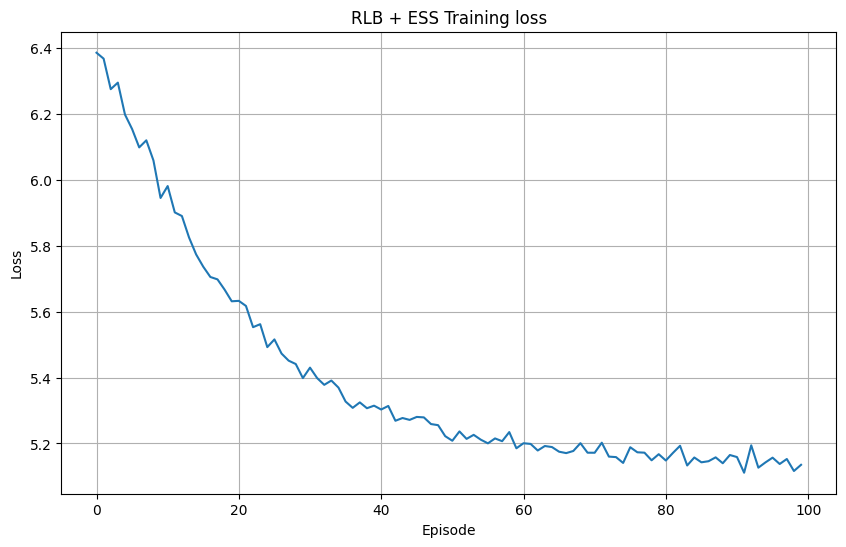

訓練完成! 最終損失: 5.135324
總執行時間: 6031.04 秒


In [14]:
# 繪製損失曲線（如果有數據）
if Loss_record:
    plt.figure(figsize=(10, 6))
    plt.plot(Loss_record)
    plt.xlabel('Episode')
    plt.ylabel('Loss')
    plt.title('RLB + ESS Training loss')
    plt.grid(True)
    plt.show()

    file_name = 'loss_rlb_ess_integrated_fixed.mat'
    savemat(file_name, {'Loss_record': Loss_record})
    print(f"訓練完成! 最終損失: {Loss_record[-1]:.6f}")
else:
    print("訓練未能產生有效結果")

print(f"總執行時間: {end - start:.2f} 秒")

# Simulate

In [15]:
def Action(state,model,env):

    w_plus=K.dot(-tf.math.abs(model.variables[0]),cell.weight_recover).numpy()
    b_plus=K.dot(-tf.math.abs(model.variables[1]),cell.bias_recover).numpy()
    w_minus=K.dot(-tf.math.abs(model.variables[2]),cell.weight_recover).numpy()
    b_minus=K.dot(-tf.math.abs(model.variables[3]),cell.bias_recover).numpy()

    omega_th_max=omega_max*K.sigmoid(model.variables[4]).numpy()
    omega_th_min=omega_min*K.sigmoid(model.variables[5]).numpy()

    treshold_min_square=np.minimum(omega_th_max**(2),omega_th_min**(2))

    d=K.dot(model.variables[6],tf.eye(dim_omega,dtype=tf.float32))

    q_plus=(model.variables[7]).numpy()
    c_plus=(-tf.math.abs(model.variables[8])).numpy()
    q_minus=(model.variables[9]).numpy()
    c_minus=(-tf.math.abs(model.variables[10])).numpy()

    def getBinaryNumpy(imgNumpy, boundary = 0):
        one = np.ones_like(imgNumpy)
        zero = np.zeros_like(imgNumpy)
        return np.where(imgNumpy > boundary, one, zero)

    states_controlled = state@cell.select_omega

    status=getBinaryNumpy(states_controlled-omega_th_max)+getBinaryNumpy(omega_th_min-states_controlled)
    A_tilde=np.transpose(A_nom*np.squeeze(status))*np.squeeze(status)
    Laplacian_tilde_diag=np.sum(A_tilde,axis=0)
    Laplacian_tilde=-A_tilde+np.diag(Laplacian_tilde_diag)

    budgets_temp=d@Laplacian_tilde

    if np.max(-budgets_temp/treshold_min_square)<1:
      budgets=budgets_temp
    else:
      budgets=(budgets_temp/(np.max(-budgets_temp/(treshold_min_square))+1e-8))

    X_alpha_plus=-np.diag(np.squeeze(states_controlled-env.omega_max*np.ones((dim_omega,))))@cell.ones_frequency.numpy()+b_plus
    X_alpha_plus[X_alpha_plus<0]=0
    alpha_plus=np.sum(X_alpha_plus*w_plus,axis=1)
    X_alpha_minus=-np.diag(np.squeeze(env.omega_min*np.ones((cell.action_units,))-states_controlled))@cell.ones_frequency.numpy()+b_minus
    X_alpha_minus[X_alpha_minus<0]=0
    alpha_minus = np.sum(X_alpha_minus*w_minus,axis=1)

    q_xp = env.E*states_controlled+(np.sin(state@cell.select_lambda)@D_reactance)@D-np.squeeze(Pm)

    X_control_plus=np.diag(np.squeeze(states_controlled-omega_th_max))@cell.ones_frequency.numpy()+c_plus
    X_control_plus[X_control_plus<0]=0
    control_plus = np.sum(X_control_plus*q_plus,axis=1)
    X_control_minus=-np.diag(np.squeeze(states_controlled-omega_th_min))@cell.ones_frequency.numpy()+c_minus
    X_control_minus[X_control_minus<0]=0
    control_minus = K.sum(X_control_minus*q_minus,axis=1)
    control=control_plus+control_minus

    nonlinear_plus = getBinaryNumpy(states_controlled-omega_th_max, boundary=0)*\
                        np.minimum(np.minimum(states_controlled+budgets*((states_controlled+1e-8)**(-1)), -alpha_plus*((states_controlled-omega_th_max+1e-8)**(-1))+q_xp), control)
    nonlinear_minus = getBinaryNumpy(omega_th_min-states_controlled, boundary=0)*\
                        np.maximum(np.maximum(states_controlled+budgets*((states_controlled+1e-8)**(-1)), alpha_minus*((omega_th_min-states_controlled+1e-8)**(-1))+q_xp), control)
    #
    action = nonlinear_plus + nonlinear_minus

    # action = tf.math.minimum(tf.math.maximum(-3*tf.ones((1,dim_omega)),action),3*tf.ones((1,dim_omega))) ### projection

    return action


<>:67: SyntaxWarning: invalid escape sequence '\o'
<>:77: SyntaxWarning: invalid escape sequence '\l'
<>:67: SyntaxWarning: invalid escape sequence '\o'
<>:77: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-4216489962.py:67: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$\omega$ (rad/s)', fontsize=14)
/tmp/ipython-input-4216489962.py:77: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\lambda$ (rad)', fontsize=14)


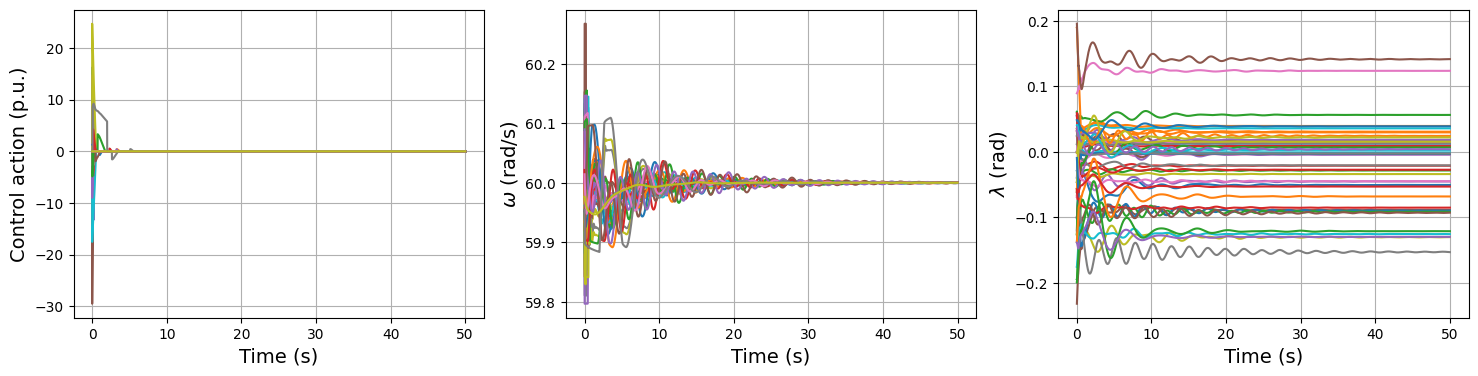

In [16]:
# Compare the trajectory

Trajectory_RNN_omega=[]
Trajectory_RNN_omega_true=[]
Trajectory_RNN_lambda=[]

init_state=equilibrium_init + s_concate

# init_state=env.reset()
s=init_state
s_record_all_omega = s@env.select_omega
s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_omega))
s_record_all_lambda = s@env.select_lambda
env.set_state(s)
Trajectory_RNN_omega.append(s_record_all_omega)
Trajectory_RNN_omega_true.append(s_record_all_omega_true)
Trajectory_RNN_lambda.append(s_record_all_lambda)
Test_time=50
SimulationLength=int(Test_time/delta_t)
Record_u=[]
Record_Loss=[]
Loss_RNN=0
Loss_RNN_discounted=0

generator_loss_node = 38
generator_loss_start_time = 0
generator_loss_period = 2
for i in range(SimulationLength):
    if i>=generator_loss_start_time/delta_t and i<=(generator_loss_start_time+generator_loss_period)/delta_t:
      Pm[0,generator_loss_node-1] = 0
    else:
      Pm[0,generator_loss_node-1] = Pm_nominal[0,generator_loss_node-1]
    u=Action(s,layer,env)
    next_s, r= env.step(u,Pm)
    Loss_RNN_discounted+=r
    Loss_RNN+=r
    s=next_s
    s_record_all_omega = s@env.select_omega
    s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_omega))
    s_record_all_lambda = s@env.select_lambda
    Trajectory_RNN_omega.append(s_record_all_omega)
    Trajectory_RNN_omega_true.append(s_record_all_omega_true)
    Trajectory_RNN_lambda.append(s_record_all_lambda)
    Record_u.append(u)
    Record_Loss.append(np.squeeze(r))
Trajectory_RNN_omega=np.squeeze(np.asarray(Trajectory_RNN_omega))
Trajectory_RNN_omega_true=np.squeeze(np.asarray(Trajectory_RNN_omega_true))
Trajectory_RNN_lambda=np.squeeze(np.asarray(Trajectory_RNN_lambda))
Record_u=np.squeeze(np.asarray(Record_u))
plt.figure(figsize=(18, 4), dpi=100)
TimeRecord=np.arange(1,SimulationLength+1)
TimeRecord=env.delta_t*TimeRecord
plt.subplot(1,3,1)

plt.plot(TimeRecord,Record_u)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Control action (p.u.)', fontsize=14)
plt.grid()

plt.subplot(1,3,2)

TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_RNN_omega_true)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\omega$ (rad/s)', fontsize=14)
plt.grid()

plt.subplot(1,3,3)

TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_RNN_lambda)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\lambda$ (rad)', fontsize=14)
plt.grid()

In [17]:
(np.sum(np.power(Record_u,2))+env.Penalty_action*np.sum(np.power(Trajectory_RNN_omega,2)))/(50/0.0008)

np.float64(10.254753041351798)

In [18]:
from scipy.io import loadmat
from scipy.io import savemat

w_plus=K.dot(-tf.math.abs(model.variables[0]),cell.weight_recover).numpy()
b_plus=K.dot(-tf.math.abs(model.variables[1]),cell.bias_recover).numpy()
w_minus=K.dot(-tf.math.abs(model.variables[2]),cell.weight_recover).numpy()
b_minus=K.dot(-tf.math.abs(model.variables[3]),cell.bias_recover).numpy()

omega_th_max=(omega_max*K.sigmoid(model.variables[4])).numpy()
omega_th_min=(omega_min*K.sigmoid(model.variables[5])).numpy()

d=(K.dot(model.variables[6],tf.eye(dim_omega,dtype=tf.float32))).numpy()

q_plus=(model.variables[7]).numpy()
c_plus=(-tf.math.abs(model.variables[8])).numpy()
q_minus=(model.variables[9]).numpy()
c_minus=(-tf.math.abs(model.variables[10])).numpy()

file_name='optimal_controllers_budgets.mat'
savemat(file_name,{'w_plus':w_plus,'w_minus':w_minus,'b_plus':b_plus,'b_minus':b_minus,'omega_th_max':omega_th_max,'omega_th_min':omega_th_min,'q_plus':q_plus,'q_minus':q_minus,'c_plus':c_plus,'c_minus':c_minus,'d':d})

In [23]:
# # Simulate - 修改版本，添加ESS監控

def Action(state, model, env):
    """修改後的動作函數，包含ESS安全信息"""
    w_plus = K.dot(-tf.math.abs(model.variables[0]), cell.weight_recover).numpy()
    b_plus = K.dot(-tf.math.abs(model.variables[1]), cell.bias_recover).numpy()
    w_minus = K.dot(-tf.math.abs(model.variables[2]), cell.weight_recover).numpy()
    b_minus = K.dot(-tf.math.abs(model.variables[3]), cell.bias_recover).numpy()

    omega_th_max = omega_max * K.sigmoid(model.variables[4]).numpy()
    omega_th_min = omega_min * K.sigmoid(model.variables[5]).numpy()

    treshold_min_square = np.minimum(omega_th_max**(2), omega_th_min**(2))

    d = K.dot(model.variables[6], tf.eye(dim_omega, dtype=tf.float32))

    q_plus = (model.variables[7]).numpy()
    c_plus = (-tf.math.abs(model.variables[8])).numpy()
    q_minus = (model.variables[9]).numpy()
    c_minus = (-tf.math.abs(model.variables[10])).numpy()

    # ESS 參數
    thr_upper = K.sigmoid(model.variables[11]).numpy()
    thr_lower = K.sigmoid(model.variables[12]).numpy()

    def getBinaryNumpy(imgNumpy, boundary=0):
        one = np.ones_like(imgNumpy)
        zero = np.zeros_like(imgNumpy)
        return np.where(imgNumpy > boundary, one, zero)

    states_controlled = state @ cell.select_omega

    status = getBinaryNumpy(states_controlled - omega_th_max) + getBinaryNumpy(omega_th_min - states_controlled)
    A_tilde = np.transpose(A_nom * np.squeeze(status)) * np.squeeze(status)
    Laplacian_tilde_diag = np.sum(A_tilde, axis=0)
    Laplacian_tilde = -A_tilde + np.diag(Laplacian_tilde_diag)

    budgets_temp = d @ Laplacian_tilde

    if np.max(-budgets_temp / treshold_min_square) < 1:
        budgets = budgets_temp
    else:
        budgets = (budgets_temp / (np.max(-budgets_temp / (treshold_min_square)) + 1e-8))

    X_alpha_plus = -np.diag(np.squeeze(states_controlled - env.omega_max * np.ones((dim_omega,)))) @ cell.ones_frequency.numpy() + b_plus
    X_alpha_plus[X_alpha_plus < 0] = 0
    alpha_plus = np.sum(X_alpha_plus * w_plus, axis=1)
    X_alpha_minus = -np.diag(np.squeeze(env.omega_min * np.ones((cell.action_units,)) - states_controlled)) @ cell.ones_frequency.numpy() + b_minus
    X_alpha_minus[X_alpha_minus < 0] = 0
    alpha_minus = np.sum(X_alpha_minus * w_minus, axis=1)

    q_xp = env.E * states_controlled + (np.sin(state @ cell.select_lambda) @ D_reactance) @ D - np.squeeze(Pm)

    X_control_plus = np.diag(np.squeeze(states_controlled - omega_th_max)) @ cell.ones_frequency.numpy() + c_plus
    X_control_plus[X_control_plus < 0] = 0
    control_plus = np.sum(X_control_plus * q_plus, axis=1)
    X_control_minus = -np.diag(np.squeeze(states_controlled - omega_th_min)) @ cell.ones_frequency.numpy() + c_minus
    X_control_minus[X_control_minus < 0] = 0
    control_minus = np.sum(X_control_minus * q_minus, axis=1)
    control = control_plus + control_minus

    nonlinear_plus = getBinaryNumpy(states_controlled - omega_th_max, boundary=0) * \
                    np.minimum(np.minimum(states_controlled + budgets * ((states_controlled + 1e-8)**(-1)),
                                         -alpha_plus * ((states_controlled - omega_th_max + 1e-8)**(-1)) + q_xp), control)
    nonlinear_minus = getBinaryNumpy(omega_th_min - states_controlled, boundary=0) * \
                     np.maximum(np.maximum(states_controlled + budgets * ((states_controlled + 1e-8)**(-1)),
                                          alpha_minus * ((omega_th_min - states_controlled + 1e-8)**(-1)) + q_xp), control)

    base_action = nonlinear_plus + nonlinear_minus

    # ==================== ESS 安全過濾 ====================
    # 簡化的ESS狀態模擬（實際應用中應從環境狀態獲取）
    # 這裡我們模擬一個簡單的ESS狀態動態
    if not hasattr(env, 'ess_state'):
        env.ess_state = np.zeros((1, dim_omega), dtype=np.float32)

    # 更新ESS狀態（簡化模型）
    env.ess_state = env.ess_state - base_action * delta_t * 0.1  # 0.1是轉換係數

    # ESS 安全參數
    E_upper = 0.3
    E_lower = -0.3
    Pe_upper = 1.0
    Pe_lower = -1.0

    boundary_upper = thr_upper * E_upper
    boundary_lower = thr_lower * E_lower

    upper_barrier = (E_upper - env.ess_state) / (E_upper - boundary_upper + 1e-8)
    lower_barrier = (env.ess_state - E_lower) / (boundary_lower - E_lower + 1e-8)

    def get_inside_bound_numpy(E, lower, upper):
        return np.logical_and(E >= lower, E <= upper).astype(np.float32)

    def get_beyond_bound_numpy(E, upper):
        return (E > upper).astype(np.float32)

    def get_below_bound_numpy(E, lower):
        return (E < lower).astype(np.float32)

    # 應用ESS安全過濾
    final_action = (
        get_inside_bound_numpy(env.ess_state, boundary_lower, boundary_upper) * base_action +
        get_beyond_bound_numpy(env.ess_state, boundary_upper) * np.minimum(base_action, upper_barrier * base_action) +
        get_below_bound_numpy(env.ess_state, boundary_lower) * np.maximum(base_action, lower_barrier * base_action)
    )

    action = np.minimum(np.maximum(final_action, Pe_lower), Pe_upper)

    # 收集安全信息用於可視化
    safety_info = {
        'base_action': base_action,
        'final_action': final_action,
        'ess_state': env.ess_state.copy(),
        'boundary_upper': boundary_upper,
        'boundary_lower': boundary_lower,
        'upper_barrier': upper_barrier,
        'lower_barrier': lower_barrier
    }

    return action, safety_info

# 比較軌跡 - 修改版本，添加ESS監控

Trajectory_RNN_omega = []
Trajectory_RNN_omega_true = []
Trajectory_RNN_lambda = []
Trajectory_ESS_State = []  # 新增：ESS狀態記錄
Trajectory_Safety_Info = []  # 新增：安全信息記錄

init_state = equilibrium_init + s_concate

# 初始化ESS狀態
env.ess_state = np.zeros((1, dim_omega), dtype=np.float32)

s = init_state
s_record_all_omega = s @ env.select_omega
s_record_all_omega_true = s_record_all_omega + 60 * np.ones((1, dim_omega))
s_record_all_lambda = s @ env.select_lambda
env.set_state(s)

Trajectory_RNN_omega.append(s_record_all_omega)
Trajectory_RNN_omega_true.append(s_record_all_omega_true)
Trajectory_RNN_lambda.append(s_record_all_lambda)
Trajectory_ESS_State.append(env.ess_state.copy())  # 記錄初始ESS狀態

Test_time = 50
SimulationLength = int(Test_time / delta_t)
Record_u = []
Record_Loss = []
Loss_RNN = 0
Loss_RNN_discounted = 0

generator_loss_node = 38
generator_loss_start_time = 0
generator_loss_period = 2

print("開始模擬 RLB + ESS 整合控制器...")
for i in range(SimulationLength):
    if i >= generator_loss_start_time / delta_t and i <= (generator_loss_start_time + generator_loss_period) / delta_t:
        Pm[0, generator_loss_node - 1] = 0
    else:
        Pm[0, generator_loss_node - 1] = Pm_nominal[0, generator_loss_node - 1]

    u, safety_info = Action(s, layer, env)  # 修改：現在返回動作和安全信息
    next_s, r = env.step(u, Pm)
    Loss_RNN_discounted += r
    Loss_RNN += r
    s = next_s

    s_record_all_omega = s @ env.select_omega
    s_record_all_omega_true = s_record_all_omega + 60 * np.ones((1, dim_omega))
    s_record_all_lambda = s @ env.select_lambda

    Trajectory_RNN_omega.append(s_record_all_omega)
    Trajectory_RNN_omega_true.append(s_record_all_omega_true)
    Trajectory_RNN_lambda.append(s_record_all_lambda)
    Trajectory_ESS_State.append(env.ess_state.copy())  # 記錄ESS狀態
    Trajectory_Safety_Info.append(safety_info)  # 記錄安全信息

    Record_u.append(u)
    Record_Loss.append(np.squeeze(r))

    if i % 500 == 0:
        print(f"模擬進度: {i}/{SimulationLength}")

Trajectory_RNN_omega = np.squeeze(np.asarray(Trajectory_RNN_omega))
Trajectory_RNN_omega_true = np.squeeze(np.asarray(Trajectory_RNN_omega_true))
Trajectory_RNN_lambda = np.squeeze(np.asarray(Trajectory_RNN_lambda))
Trajectory_ESS_State = np.squeeze(np.asarray(Trajectory_ESS_State))  # 轉換為numpy數組
Record_u = np.squeeze(np.asarray(Record_u))


開始模擬 RLB + ESS 整合控制器...
模擬進度: 0/62500
模擬進度: 500/62500
模擬進度: 1000/62500
模擬進度: 1500/62500
模擬進度: 2000/62500
模擬進度: 2500/62500
模擬進度: 3000/62500
模擬進度: 3500/62500
模擬進度: 4000/62500
模擬進度: 4500/62500
模擬進度: 5000/62500
模擬進度: 5500/62500
模擬進度: 6000/62500
模擬進度: 6500/62500
模擬進度: 7000/62500
模擬進度: 7500/62500
模擬進度: 8000/62500
模擬進度: 8500/62500
模擬進度: 9000/62500
模擬進度: 9500/62500
模擬進度: 10000/62500
模擬進度: 10500/62500
模擬進度: 11000/62500
模擬進度: 11500/62500
模擬進度: 12000/62500
模擬進度: 12500/62500
模擬進度: 13000/62500
模擬進度: 13500/62500
模擬進度: 14000/62500
模擬進度: 14500/62500
模擬進度: 15000/62500
模擬進度: 15500/62500
模擬進度: 16000/62500
模擬進度: 16500/62500
模擬進度: 17000/62500
模擬進度: 17500/62500
模擬進度: 18000/62500
模擬進度: 18500/62500
模擬進度: 19000/62500
模擬進度: 19500/62500
模擬進度: 20000/62500
模擬進度: 20500/62500
模擬進度: 21000/62500
模擬進度: 21500/62500
模擬進度: 22000/62500
模擬進度: 22500/62500
模擬進度: 23000/62500
模擬進度: 23500/62500
模擬進度: 24000/62500
模擬進度: 24500/62500
模擬進度: 25000/62500
模擬進度: 25500/62500
模擬進度: 26000/62500
模擬進度: 26500/62500
模擬進度: 27000/62500
模擬進度: 2750

/tmp/ipython-input-3746714694.py:293: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ess_energy_change = np.trapz(np.abs(Record_u), axis=0) * delta_t  # 使用絕對值來計算總能量


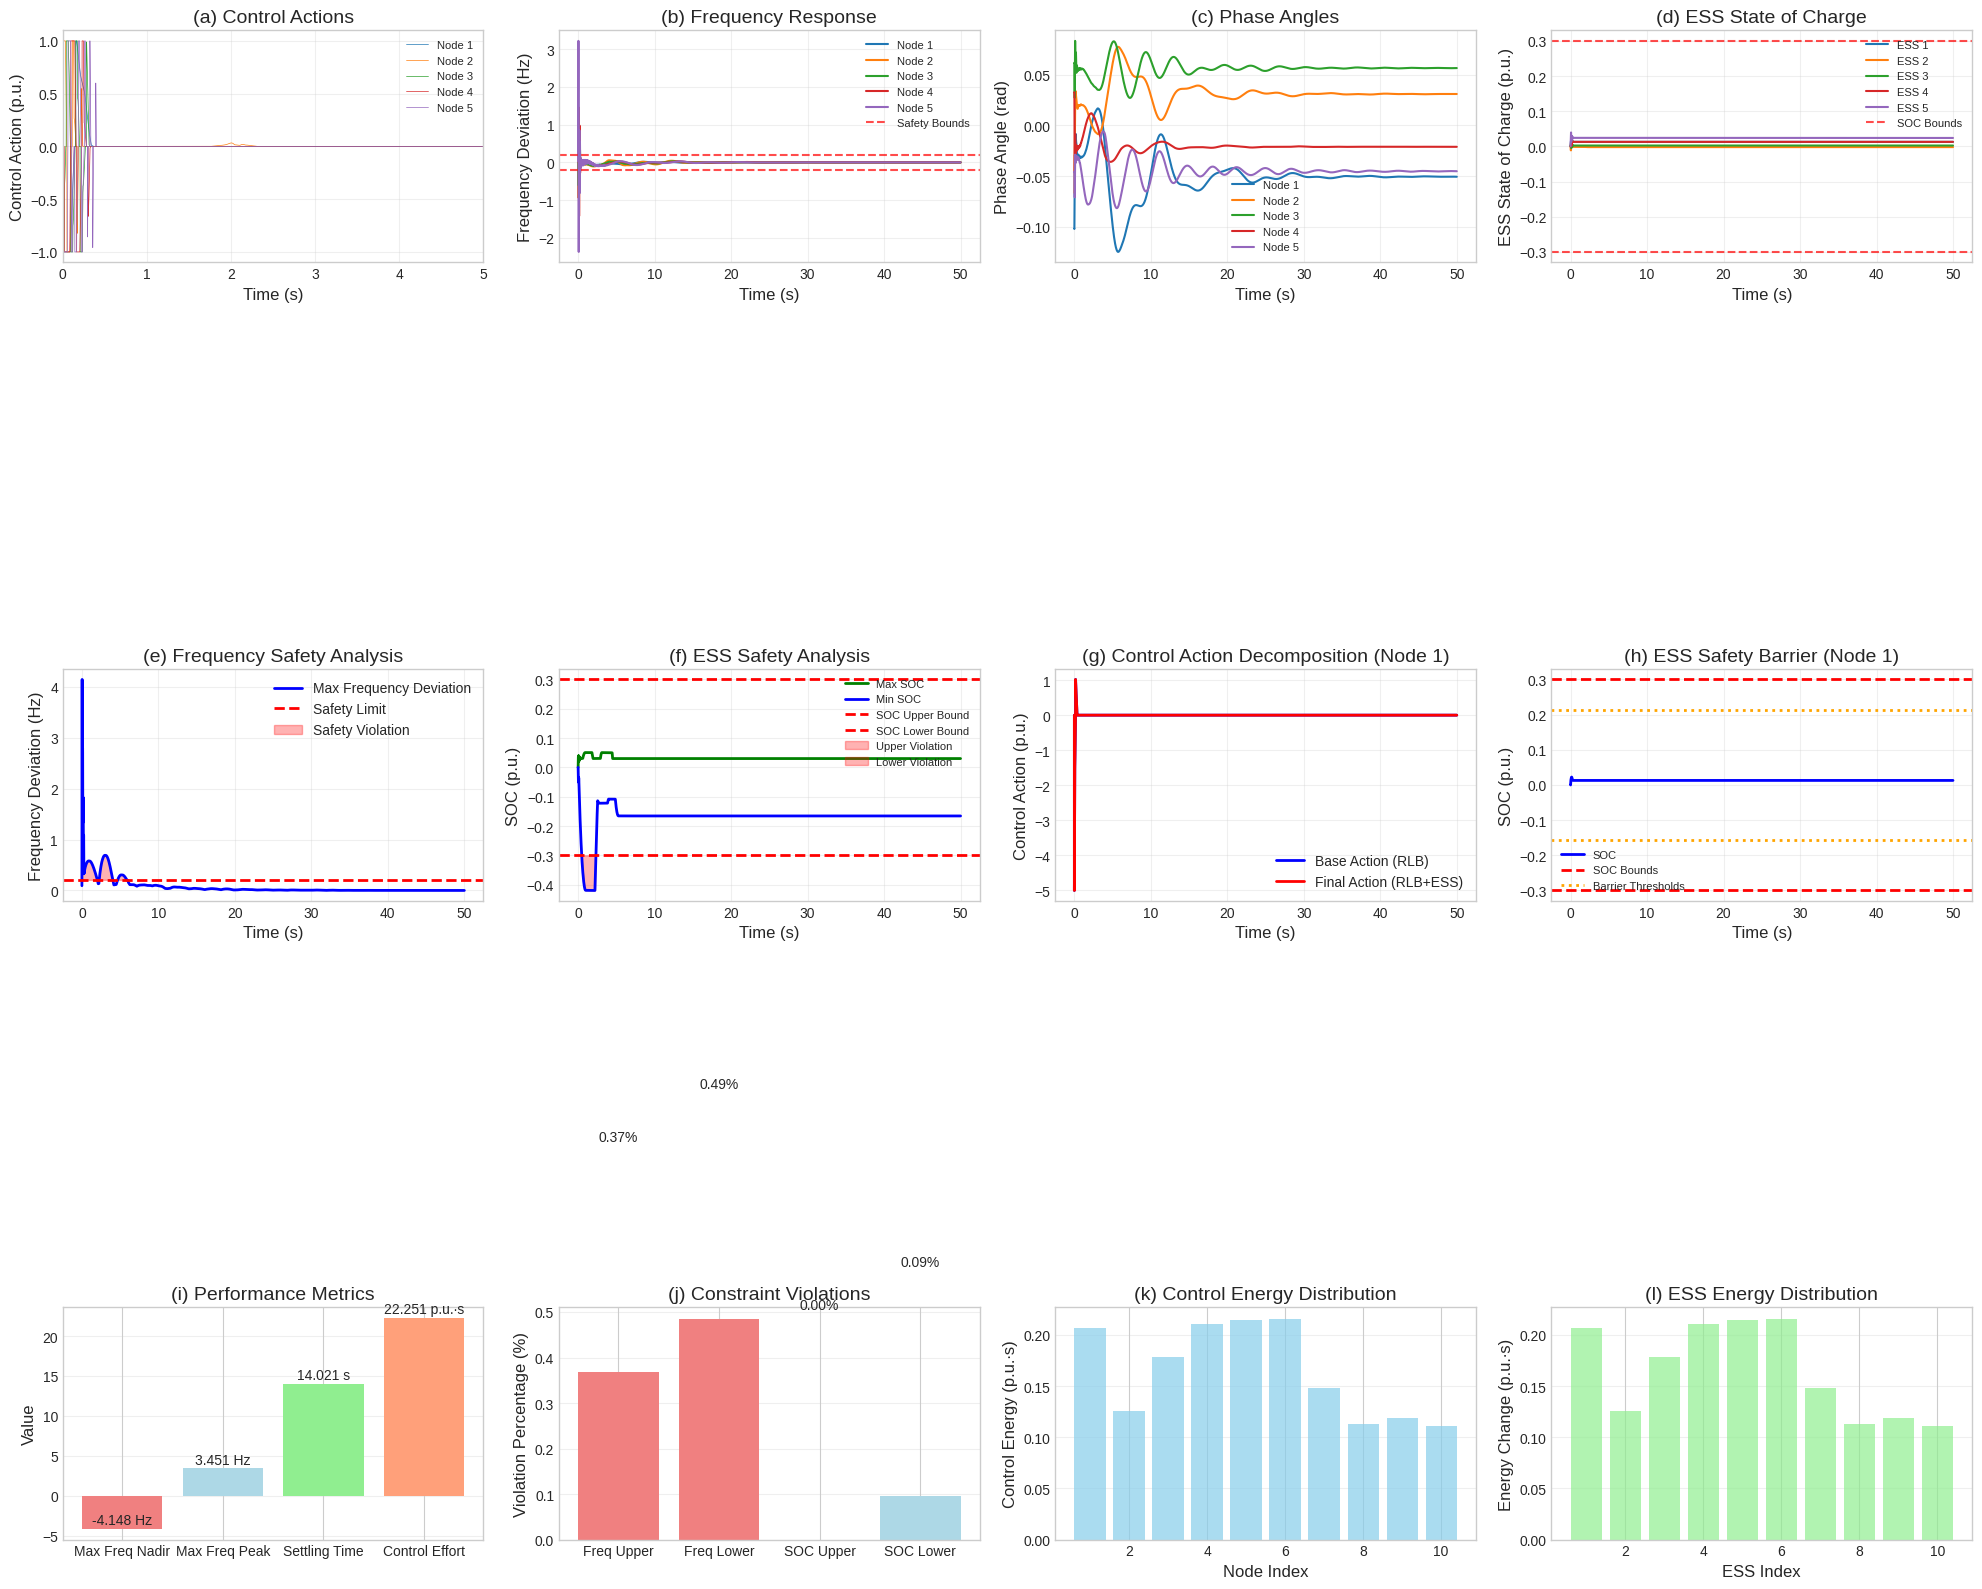


RLB + ESS INTEGRATED CONTROLLER PERFORMANCE SUMMARY
Maximum Frequency Nadir: -4.1484 Hz
Maximum Frequency Peak: 3.4506 Hz
Settling Time (to ±0.02 Hz): 14.02 s
Total Control Effort: 22.2509 p.u.·s
Frequency Constraint Violations: 0.85%
SOC Constraint Violations: 0.09%

保存模擬結果...
模擬完成！結果已保存。


In [43]:
# ==================== 增強的可視化 ====================

# 設置繪圖風格
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 16), dpi=100)

# 時間軸
TimeRecord_full = np.arange(0, SimulationLength + 1) * env.delta_t
TimeRecord_action = np.arange(0, SimulationLength) * env.delta_t

# 1. 控制動作
plt.subplot(3, 4, 1)
for i in range(min(5, dim_omega)):  # 只顯示前5個以保持清晰
    plt.plot(TimeRecord_action, Record_u[:, i], label=f'Node {i+1}', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.xlim(0,5) #set the x-axis range from 0 to
plt.ylabel('Control Action (p.u.)', fontsize=12)
plt.title('(a) Control Actions', fontsize=14)
plt.legend(fontsize=8)

# 2. 頻率響應
plt.subplot(3, 4, 2)
for i in range(min(5, dim_omega)):
    plt.plot(TimeRecord_full, Trajectory_RNN_omega[:, i], label=f'Node {i+1}', linewidth=1.5)
plt.axhline(y=omega_max, color='r', linestyle='--', alpha=0.7, label='Safety Bounds')
plt.axhline(y=omega_min, color='r', linestyle='--', alpha=0.7)
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Frequency Deviation (Hz)', fontsize=12)
plt.title('(b) Frequency Response', fontsize=14)
plt.legend(fontsize=8)

# 3. 相角
plt.subplot(3, 4, 3)
for i in range(min(5, dim_omega)):
    plt.plot(TimeRecord_full, Trajectory_RNN_lambda[:, i], label=f'Node {i+1}', linewidth=1.5)
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Phase Angle (rad)', fontsize=12)
plt.title('(c) Phase Angles', fontsize=14)
plt.legend(fontsize=8)

# 4. ESS 狀態
plt.subplot(3, 4, 4)
for i in range(min(5, dim_omega)):
    plt.plot(TimeRecord_full, Trajectory_ESS_State[:, i], label=f'ESS {i+1}', linewidth=1.5)
plt.axhline(y=0.3, color='r', linestyle='--', alpha=0.7, label='SOC Bounds')
plt.axhline(y=-0.3, color='r', linestyle='--', alpha=0.7)
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('ESS State of Charge (p.u.)', fontsize=12)
plt.title('(d) ESS State of Charge', fontsize=14)
plt.legend(fontsize=8)

# 5. 頻率安全分析
plt.subplot(3, 4, 5)
max_freq_deviation = np.max(np.abs(Trajectory_RNN_omega), axis=1)
plt.plot(TimeRecord_full, max_freq_deviation, 'b-', linewidth=2, label='Max Frequency Deviation')
plt.axhline(y=omega_max, color='r', linestyle='--', linewidth=2, label='Safety Limit')
plt.fill_between(TimeRecord_full, max_freq_deviation, omega_max,
                 where=(max_freq_deviation > omega_max), color='red', alpha=0.3, label='Safety Violation')
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Frequency Deviation (Hz)', fontsize=12)
plt.title('(e) Frequency Safety Analysis', fontsize=14)
plt.legend(fontsize=10)

# 6. ESS 安全分析
plt.subplot(3, 4, 6)
max_soc = np.max(Trajectory_ESS_State, axis=1)
min_soc = np.min(Trajectory_ESS_State, axis=1)
plt.plot(TimeRecord_full, max_soc, 'g-', linewidth=2, label='Max SOC')
plt.plot(TimeRecord_full, min_soc, 'b-', linewidth=2, label='Min SOC')
plt.axhline(y=0.3, color='r', linestyle='--', linewidth=2, label='SOC Upper Bound')
plt.axhline(y=-0.3, color='r', linestyle='--', linewidth=2, label='SOC Lower Bound')
plt.fill_between(TimeRecord_full, max_soc, 0.3,
                 where=(max_soc > 0.3), color='red', alpha=0.3, label='Upper Violation')
plt.fill_between(TimeRecord_full, min_soc, -0.3,
                 where=(min_soc < -0.3), color='red', alpha=0.3, label='Lower Violation')
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('SOC (p.u.)', fontsize=12)
plt.title('(f) ESS Safety Analysis', fontsize=14)
plt.legend(fontsize=8)

# 7. 控制動作分解（第一個節點）
plt.subplot(3, 4, 7)
if len(Trajectory_Safety_Info) > 0:
    node_idx = 0  # 查看第一個節點

    base_actions = []
    final_actions = []

    for info in Trajectory_Safety_Info:
        if 'base_action' in info:
            # 安全地提取數據
            base_action_data = info['base_action']
            if hasattr(base_action_data, '__len__') and len(base_action_data) > 0:
                if hasattr(base_action_data[0], '__len__') and len(base_action_data[0]) > node_idx:
                    base_actions.append(base_action_data[0][node_idx])
                elif len(base_action_data) > node_idx:
                    base_actions.append(base_action_data[node_idx])
                else:
                    base_actions.append(0.0)
            else:
                base_actions.append(0.0)
        else:
            base_actions.append(0.0)

        if 'final_action' in info:
            # 安全地提取數據
            final_action_data = info['final_action']
            if hasattr(final_action_data, '__len__') and len(final_action_data) > 0:
                if hasattr(final_action_data[0], '__len__') and len(final_action_data[0]) > node_idx:
                    final_actions.append(final_action_data[0][node_idx])
                elif len(final_action_data) > node_idx:
                    final_actions.append(final_action_data[node_idx])
                else:
                    final_actions.append(0.0)
            else:
                final_actions.append(0.0)
        else:
            final_actions.append(0.0)

    if len(base_actions) == len(TimeRecord_action):
        plt.plot(TimeRecord_action, base_actions, 'b-', linewidth=2, label='Base Action (RLB)')
        plt.plot(TimeRecord_action, final_actions, 'r-', linewidth=2, label='Final Action (RLB+ESS)')
        plt.grid(True, alpha=0.3)
        plt.xlabel('Time (s)', fontsize=12)
        plt.ylabel('Control Action (p.u.)', fontsize=12)
        plt.title('(g) Control Action Decomposition (Node 1)', fontsize=14)
        plt.legend(fontsize=10)

# 8. ESS 安全屏障效果
plt.subplot(3, 4, 8)
if len(Trajectory_Safety_Info) > 0:
    node_idx = 0

    ess_states = []
    upper_barriers = []
    lower_barriers = []

    for info in Trajectory_Safety_Info:
        if 'ess_state' in info:
            # 安全地提取數據
            ess_state_data = info['ess_state']
            if hasattr(ess_state_data, '__len__') and len(ess_state_data) > 0:
                if hasattr(ess_state_data[0], '__len__') and len(ess_state_data[0]) > node_idx:
                    ess_states.append(ess_state_data[0][node_idx])
                elif len(ess_state_data) > node_idx:
                    ess_states.append(ess_state_data[node_idx])
                else:
                    ess_states.append(0.0)
            else:
                ess_states.append(0.0)
        else:
            ess_states.append(0.0)

        if 'upper_barrier' in info:
            # 安全地提取數據
            upper_barrier_data = info['upper_barrier']
            if hasattr(upper_barrier_data, '__len__') and len(upper_barrier_data) > 0:
                if hasattr(upper_barrier_data[0], '__len__') and len(upper_barrier_data[0]) > node_idx:
                    upper_barriers.append(upper_barrier_data[0][node_idx])
                elif len(upper_barrier_data) > node_idx:
                    upper_barriers.append(upper_barrier_data[node_idx])
                else:
                    upper_barriers.append(1.0)
            else:
                upper_barriers.append(1.0)
        else:
            upper_barriers.append(1.0)

        if 'lower_barrier' in info:
            # 安全地提取數據
            lower_barrier_data = info['lower_barrier']
            if hasattr(lower_barrier_data, '__len__') and len(lower_barrier_data) > 0:
                if hasattr(lower_barrier_data[0], '__len__') and len(lower_barrier_data[0]) > node_idx:
                    lower_barriers.append(lower_barrier_data[0][node_idx])
                elif len(lower_barrier_data) > node_idx:
                    lower_barriers.append(lower_barrier_data[node_idx])
                else:
                    lower_barriers.append(1.0)
            else:
                lower_barriers.append(1.0)
        else:
            lower_barriers.append(1.0)

    # 安全地獲取邊界值
    boundary_upper = 0.3  # 默認值
    boundary_lower = -0.3  # 默認值

    if len(Trajectory_Safety_Info) > 0 and 'boundary_upper' in Trajectory_Safety_Info[0]:
        boundary_data = Trajectory_Safety_Info[0]['boundary_upper']
        if hasattr(boundary_data, '__len__') and len(boundary_data) > node_idx:
            boundary_upper = boundary_data[node_idx] if not hasattr(boundary_data[node_idx], '__len__') else boundary_data[node_idx][0]
        elif hasattr(boundary_data, '__len__') and len(boundary_data) > 0:
            boundary_upper = boundary_data[0] if not hasattr(boundary_data[0], '__len__') else boundary_data[0][0]

    if len(Trajectory_Safety_Info) > 0 and 'boundary_lower' in Trajectory_Safety_Info[0]:
        boundary_data = Trajectory_Safety_Info[0]['boundary_lower']
        if hasattr(boundary_data, '__len__') and len(boundary_data) > node_idx:
            boundary_lower = boundary_data[node_idx] if not hasattr(boundary_data[node_idx], '__len__') else boundary_data[node_idx][0]
        elif hasattr(boundary_data, '__len__') and len(boundary_data) > 0:
            boundary_lower = boundary_data[0] if not hasattr(boundary_data[0], '__len__') else boundary_data[0][0]

    if len(ess_states) == len(TimeRecord_action):
        plt.plot(TimeRecord_action, ess_states, 'b-', linewidth=2, label='SOC')
        plt.axhline(y=0.3, color='r', linestyle='--', linewidth=2, label='SOC Bounds')
        plt.axhline(y=-0.3, color='r', linestyle='--', linewidth=2)
        plt.axhline(y=boundary_upper, color='orange', linestyle=':', linewidth=2, label='Barrier Thresholds')
        plt.axhline(y=boundary_lower, color='orange', linestyle=':', linewidth=2)
        plt.grid(True, alpha=0.3)
        plt.xlabel('Time (s)', fontsize=12)
        plt.ylabel('SOC (p.u.)', fontsize=12)
        plt.title('(h) ESS Safety Barrier (Node 1)', fontsize=14)
        plt.legend(fontsize=8)

# 9. 性能指標總結
plt.subplot(3, 4, 9)
# 計算性能指標
max_freq_nadir = np.min(Trajectory_RNN_omega)  # 頻率最低點
max_freq_peak = np.max(Trajectory_RNN_omega)   # 頻率最高點

def calculate_settling_time(frequency_trajectory, delta_t, tolerance=0.02):
    """計算穩定時間"""
    exceeding_indices = np.where(np.abs(frequency_trajectory) > tolerance)[0]
    if len(exceeding_indices) > 0:
        last_exceed_idx = exceeding_indices[-1]
        settling_time = last_exceed_idx * delta_t
    else:
        settling_time = 0
    return settling_time

settling_times = []
for i in range(min(10, dim_omega)):  # 只計算前10個以避免過長計算
    settling_time_i = calculate_settling_time(Trajectory_RNN_omega[:, i], delta_t)
    settling_times.append(settling_time_i)

settling_time = max(settling_times) if settling_times else 0
total_control_effort = np.sum(np.abs(Record_u)) * delta_t

metrics = ['Max Freq Nadir', 'Max Freq Peak', 'Settling Time', 'Control Effort']
values = [max_freq_nadir, max_freq_peak, settling_time, total_control_effort]
units = ['Hz', 'Hz', 's', 'p.u.·s']

bars = plt.bar(metrics, values, color=['lightcoral', 'lightblue', 'lightgreen', 'lightsalmon'])
plt.ylabel('Value', fontsize=12)
plt.title('(i) Performance Metrics', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# 在柱狀圖上添加數值標籤
for bar, value, unit in zip(bars, values, units):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01 * max(values),
             f'{value:.3f} {unit}', ha='center', va='bottom', fontsize=10)

# 10. 安全約束滿足情況
plt.subplot(3, 4, 10)
# 計算約束違反情況
freq_upper_violation = np.sum(Trajectory_RNN_omega > omega_max) / Trajectory_RNN_omega.size * 100
freq_lower_violation = np.sum(Trajectory_RNN_omega < omega_min) / Trajectory_RNN_omega.size * 100
soc_upper_violation = np.sum(Trajectory_ESS_State > 0.3) / Trajectory_ESS_State.size * 100
soc_lower_violation = np.sum(Trajectory_ESS_State < -0.3) / Trajectory_ESS_State.size * 100

constraints = ['Freq Upper', 'Freq Lower', 'SOC Upper', 'SOC Lower']
violations = [freq_upper_violation, freq_lower_violation, soc_upper_violation, soc_lower_violation]

bars = plt.bar(constraints, violations, color=['lightcoral', 'lightcoral', 'lightblue', 'lightblue'])
plt.ylabel('Violation Percentage (%)', fontsize=12)
plt.title('(j) Constraint Violations', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# 在柱狀圖上添加數值標籤
for bar, violation in zip(bars, violations):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{violation:.2f}%', ha='center', va='bottom', fontsize=10)

# 11. 控制能量分布
plt.subplot(3, 4, 11)
control_energy = np.sum(np.abs(Record_u), axis=0) * delta_t
nodes = np.arange(1, min(11, dim_omega + 1))  # 只顯示前10個
plt.bar(nodes, control_energy[:len(nodes)], color='skyblue', alpha=0.7)
plt.xlabel('Node Index', fontsize=12)
plt.ylabel('Control Energy (p.u.·s)', fontsize=12)
plt.title('(k) Control Energy Distribution', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# 12. ESS 能量分布
plt.subplot(3, 4, 12)
ess_energy_change = np.trapz(np.abs(Record_u), axis=0) * delta_t  # 使用絕對值來計算總能量
nodes = np.arange(1, min(11, dim_omega + 1))
plt.bar(nodes, ess_energy_change[:len(nodes)], color='lightgreen', alpha=0.7)
plt.xlabel('ESS Index', fontsize=12)
plt.ylabel('Energy Change (p.u.·s)', fontsize=12)
plt.title('(l) ESS Energy Distribution', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ==================== 打印性能總結 ====================
print("\n" + "="*60)
print("RLB + ESS INTEGRATED CONTROLLER PERFORMANCE SUMMARY")
print("="*60)
print(f"Maximum Frequency Nadir: {max_freq_nadir:.4f} Hz")
print(f"Maximum Frequency Peak: {max_freq_peak:.4f} Hz")
print(f"Settling Time (to ±0.02 Hz): {settling_time:.2f} s")
print(f"Total Control Effort: {total_control_effort:.4f} p.u.·s")
print(f"Frequency Constraint Violations: {freq_upper_violation + freq_lower_violation:.2f}%")
print(f"SOC Constraint Violations: {soc_upper_violation + soc_lower_violation:.2f}%")
print("="*60)

# ==================== 保存結果 ====================
print("\n保存模擬結果...")
file_name = 'simulation_results_rlb_ess_integrated.mat'
savemat(file_name, {
    'Trajectory_RNN_omega': Trajectory_RNN_omega,
    'Trajectory_RNN_omega_true': Trajectory_RNN_omega_true,
    'Trajectory_RNN_lambda': Trajectory_RNN_lambda,
    'Trajectory_ESS_State': Trajectory_ESS_State,
    'Record_u': Record_u,
    'Record_Loss': Record_Loss,
    'TimeRecord_full': TimeRecord_full,
    'TimeRecord_action': TimeRecord_action
})

print("模擬完成！結果已保存。")